# Hochschule Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/03m2kj587' -- 'Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Hannover,"University of Applied Sciences and Arts, Facul...",https://openalex.org/W4402279176
1,not assigned,Hochschule Hannover,"Department for Medical Statistics, University ...",https://openalex.org/W4401728581
2,not assigned,Hochschule Hannover,"Faculty III, Hochschule Hannover University of...",https://openalex.org/W4405544408
3,not assigned,Hochschule Hannover,"Hochschule Hannover, Hannover, Deutschland",https://openalex.org/W4401369018
4,not assigned,Hochschule Hannover,"Department of Psychology, Fachhochschule des M...",https://openalex.org/W4399896416


In [107]:
MAPPING_DICT = {
    'Fakultät I - Elektro- und Informationstechnik': ['informationstechnik', 'electrical', 'sensor'],
    'Fakultät II - Maschinenbau und Bioverfahrenstechnik': ['ricklinger', 'bioprocess', 'mechanical engineering', 'microbiology', 'bioplastics',
                                                            'mechatronics', 'verfahrenstechnik', 'faculty ii,'
                                                           ],
    'Fakultät III - Medien, Information und Design': ['expo plaza', 'design and media', 'fa(k|c)ult(at|y|ät) iii', 'information and communication',
                                                      'design'
                                                     ],
    'Fakultät IV - Wirtschaft und Informatik': ['computer science', 'faculty iv'],
    'Fakultät V - Diakonie, Gesundheit und Soziales': ['soziale arbeit', 'social work', 'blumhardtstraße', 'diakonie', 'nursing', 'health'],
    'Institute for Applied Data Science Hannover (Data|H)': ['data(\|)?h', 'applied data science']
}

In [108]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [109]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [110]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"University of Applied Sciences and Arts, Facul...",https://openalex.org/W4402279176
1,"Fakultät V - Diakonie, Gesundheit und Soziales",Hochschule Hannover,"Department for Medical Statistics, University ...",https://openalex.org/W4401728581
2,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Faculty III, Hochschule Hannover University of...",https://openalex.org/W4405544408
3,None,Hochschule Hannover,"Hochschule Hannover, Hannover, Deutschland",https://openalex.org/W4401369018
4,None,Hochschule Hannover,"Department of Psychology, Fachhochschule des M...",https://openalex.org/W4399896416
...,...,...,...,...
552,None,Hochschule Hannover,"Leibniz University Hannover, Institute of Appl...",https://openalex.org/W4200606081
553,None,Hochschule Hannover,Leibniz University Hannover Institute of Appli...,https://openalex.org/W4200606081
554,None,Hochschule Hannover,University of Applied Sciences and Arts Hannov...,https://openalex.org/W4382404342
555,Fakultät II - Maschinenbau und Bioverfahrenste...,Hochschule Hannover,Department of Bioprocess Engineering and Micro...,https://openalex.org/W3008449340


In [111]:
df_with_inst[(df_with_inst.inst_name.isnull()) & df_with_inst.raw_affiliation_string.str.contains('hannover', case=False, regex=False)].raw_affiliation_string.unique()

array(['Hochschule Hannover, Hannover, Deutschland',
       'University of Applied Sciences and Arts, Hannover, Germany, 12',
       'Leibniz Universität Hannover, Institute of Applied Mathematics, Welfengarten 1, 30167 Hannover, Germany',
       'University of Applied Sciences FHDW Hannover',
       'Hochschule Hannover, Germany',
       'University of Tehran, Institute of Geophysics, Tehran, Iran and LIAG Institute for Applied Geophysics, Hannover, Germany',
       'Leibniz Universität Hannover, Institute of Horticultural Production Systems, Sect. Phytomedicine - Applied Entomology, Herrenhäuser Strasse 2, D-30419 Hannover, Germany',
       'Leibniz Universität Hannover, Institute of Horticultural Production Systems, Sect. Phytomedicine – Applied Entomology, Herrenhäuser Strasse 2, D-30419 Hannover, Germany',
       'Hannover University of Applied Sciences and Arts',
       'University of Applied Sciences and Arts Hannover,Department of Integrated Circuits and Embedded Systems,German

In [112]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Fakultät I - Elektro- und Informationstechnik,26
1,Fakultät II - Maschinenbau und Bioverfahrenste...,112
2,"Fakultät III - Medien, Information und Design",81
3,Fakultät IV - Wirtschaft und Informatik,24
4,"Fakultät V - Diakonie, Gesundheit und Soziales",30
5,Institute for Applied Data Science Hannover (D...,11
6,NaN,273


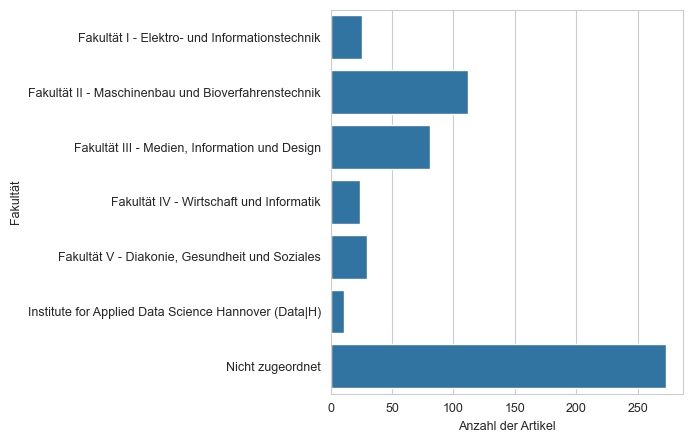

In [113]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [114]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5098743267504489